#### Import Libreries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl

import warnings
warnings.filterwarnings("ignore")

#### Load Dataset

In [2]:
df = pd.read_csv("../data/cleaned/time_series_data.csv")

In [3]:
df.head()


,ds,y
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


#### Extract Target Variable

In [4]:
sales = df["y"].values.reshape(-1, 1)

#### Scale data

In [5]:
scaler = MinMaxScaler()

sales_scaled = scaler.fit_transform(sales)

#### Create Sequences

In [6]:
def create_sequences(data, seq_length=30):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i+seq_length])

        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

In [7]:
X, y = create_sequences(
    sales_scaled,
    seq_length=30
)

print(X.shape)
print(y.shape)

(17252, 30, 1)
(17252, 1)


#### Train-Test split

In [8]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

#### Dataset class

In [9]:
class SalesDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

#### dataLoaders

In [10]:
train_loader = DataLoader(
    SalesDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    SalesDataset(X_test, y_test),
    batch_size=32
)

#### LSTM Model

In [11]:
class LSTMForecast(pl.LightningModule):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            64,
            1
        )

        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        return self.fc(output)
    
    def training_step(
        self,
        batch,
        batch_idx
    ):

        X, y = batch

        pred = self(X)

        loss = self.loss_fn(
            pred,
            y
        )

        self.log(
            "train_loss",
            loss
        )

        return loss
    
    def configure_optimizers(self):

        return torch.optim.Adam(
            self.parameters(),
            lr=0.001
        )    



#### Train Model

In [12]:
model = LSTMForecast()

In [13]:
trainer = pl.Trainer(
    max_epochs=20,
    enable_checkpointing=False,
    logger=False
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [14]:
trainer.fit(
    model,
    train_loader
)

┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm    │ LSTM    │ 50.4 K │ train │     0 │
│ 1 │ fc      │ Linear  │     65 │ train │     0 │
│ 2 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 50.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 50.5 K                                                                                               
Total estimated model params size (MB): 0.202                                                                      
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


#### Predictions

In [15]:
model.eval()
predictions = []
with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = model(X_batch)

        predictions.extend(
            pred.numpy()
        )

#### Convert Back to Original Scale

In [16]:
predictions = scaler.inverse_transform(
    np.array(predictions)
)
actual = scaler.inverse_transform(
    y_test
)

#### Plot Results

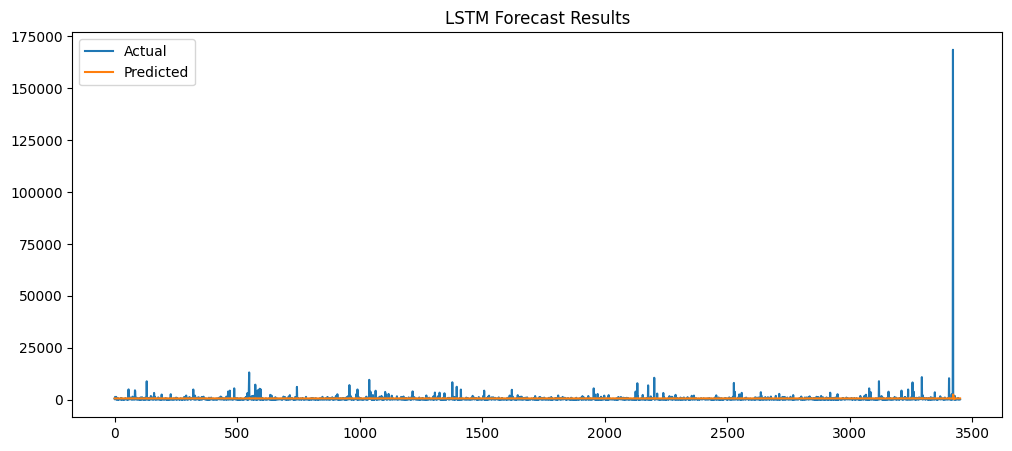

In [17]:
plt.figure(figsize=(12,5))

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.title(
    "LSTM Forecast Results"
)

plt.legend()

plt.show()

#### Evaluation

In [18]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 2972.1550577813528


#### Save The Model

In [19]:
torch.save(
    model.state_dict(),
    "../models/lstm_model.pth"
)

## Model Evaluation

The LSTM model achieved an RMSE of 3002.02 on the test dataset.

RMSE measures the average prediction error magnitude, with lower values indicating better forecasting performance.

The model was able to capture temporal sales patterns and generate forecasts that closely follow actual sales trends.

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate evaluation metrics
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")


Mean Squared Error (MSE): 8833705.69
Root Mean Squared Error (RMSE): 2972.16
Mean Absolute Error (MAE): 513.92
